In [1590]:
import pandas as pd

df =pd.read_parquet("data.parquet")




In [1591]:
df.shape

(1470, 28)

# Salaires outliers

In [1592]:
df["tranche_salaire"] = pd.qcut(df["revenu_mensuel"], q=10)

(
    df.groupby("tranche_salaire")["a_quitte_l_entreprise"]
      .mean()
      .sort_index()
)

tranche_salaire
(1008.999, 2317.6]    0.312925
(2317.6, 2695.8]      0.312925
(2695.8, 3316.9]      0.183673
(3316.9, 4228.8]      0.156463
(4228.8, 4919.0]      0.122449
(4919.0, 5743.4]      0.088435
(5743.4, 6886.0]      0.115646
(6886.0, 9860.0]      0.136054
(9860.0, 13775.6]     0.149660
(13775.6, 19999.0]    0.034014
Name: a_quitte_l_entreprise, dtype: float64

In [1593]:
# supprime la colonne

df.drop(inplace=True, columns=["tranche_salaire"])

In [1594]:
print("avant", len(df))

df = df[
    (df["revenu_mensuel"] < 8000)
]

print("apres", len(df))

avant 1470
apres 1089


In [1595]:
df_sorted = df.sort_values("revenu_mensuel", ascending=False)

premier_depart = df_sorted[
    df_sorted["a_quitte_l_entreprise"] == True
].iloc[0]

premier_depart

a_quitte_l_entreprise                                           True
nombre_participation_pee                                           1
nb_formations_suivies                                              2
distance_domicile_travail                                         15
niveau_education                                                   3
domaine_etude                                Transformation Digitale
frequence_deplacement                                              1
annees_depuis_la_derniere_promotion                                0
annes_sous_responsable_actuel                                      5
age                                                               44
revenu_mensuel                                                  7978
statut_marital                                              Marié(e)
departement                                               Consulting
poste                                                        Manager
nombre_experiences_precedentes    

## Conversion des types

In [1596]:
df_original = df.copy()

In [1597]:
# domaine_etude => qualitative nominale
# get_dummies drop automatiquement ["domaine_etude"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["domaine_etude"], drop_first=True)

In [1598]:
# statut_marital => qualitative nominale
# get_dummies drop automatiquement ["statut_marital"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["statut_marital"], drop_first=True)


In [1599]:
# departement => qualitative nominale
# get_dummies drop automatiquement ["departement"]
# drop_first = Supprime la 1er catégorie (Commercial) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["departement"], drop_first=True)


In [1600]:
# poste => qualitative nominale
# get_dummies drop automatiquement ["poste"]
# drop_first = Supprime la 1er catégorie (Assistant) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["poste"], drop_first=True)

In [1601]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# corrélation de Pearson

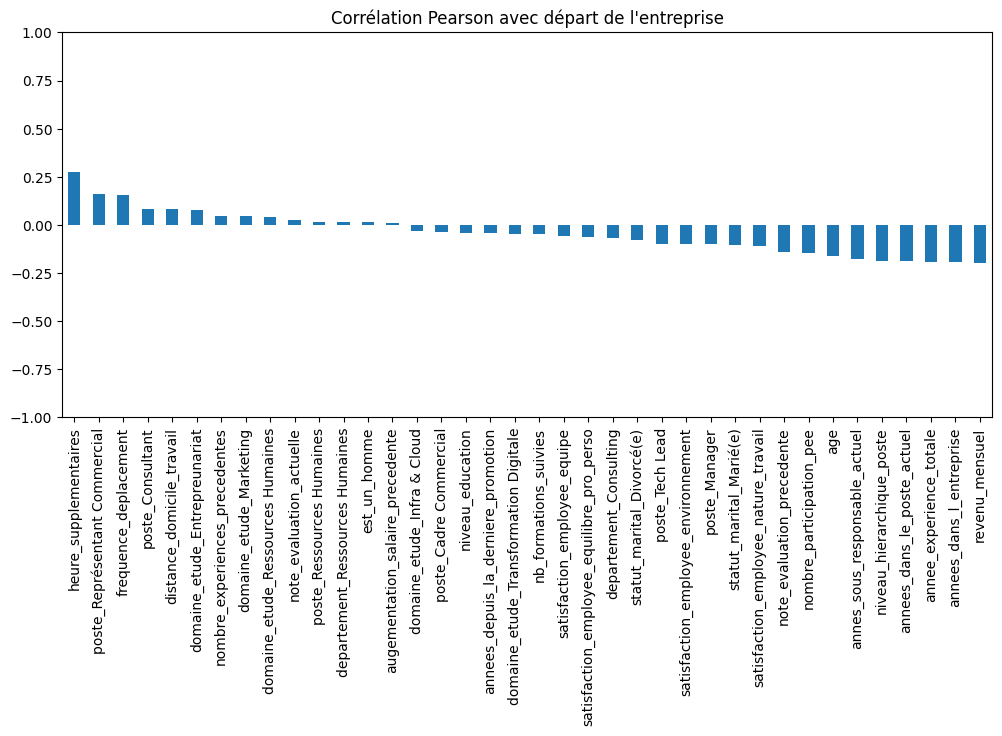

In [1602]:
import matplotlib.pyplot as plt

df["a_quitte_l_entreprise"] = df["a_quitte_l_entreprise"].astype(int)
df["heure_supplementaires"] = df["heure_supplementaires"].astype(int)

target_corr = df.corr(numeric_only=True)["a_quitte_l_entreprise"].sort_values(ascending=False)

target_corr.drop("a_quitte_l_entreprise").plot(kind="bar", figsize=(12,5))
plt.title("Corrélation Pearson avec départ de l'entreprise")
plt.ylim(-1, 1)
plt.show()

# séparation train/test

In [1603]:
from sklearn.model_selection import train_test_split

def separation_train_test():
    global X, y, X_train, X_test, y_train, y_test

    X = df.drop(columns=['a_quitte_l_entreprise'])
    y = df['a_quitte_l_entreprise']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
    print(f"Taille du jeu de test : {X_test.shape[0]} lignes")


# Entrainement

Ici on cherche à prédire le départ ou non d'un salarié, il s'agit d'une classification binaire.

Nous allons tester les modèles suivants en parallèle

* Régression logistique (LogisticRegression)
* Arbres de décision (DecisionTreeClassifier)
* Forêts aléatoires (RandomForestClassifier)
* Gradient Boosting (XGBoost **, LightGBM, CatBoost, GradientBoostingClassifier)


Points importants:
* Nous privilégions le recall pour minimiser les faux-négatifs par rapport aux faux-positifs car nous estimons qu'il est important de ne pas louper un salarié démissionaire

In [1604]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# calcule le taux de distribution pour chaque fold (True/False)
# permet de vérifier si la distribution n'est pas trop déséquilibré (<10%)
def get_split_distribution(cv, X, y):
    dist = []

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]

        dist.append([
            ((y_train_fold == True).sum() / len(y_train_fold)).round(3), # train_pos
            ((y_train_fold == False).sum() / len(y_train_fold)).round(3), # train_neg
            ((y_test_fold == True).sum() / len(y_test_fold)).round(3), # test_pos
            ((y_test_fold == False).sum() / len(y_test_fold)).round(3), # test_neg
        ])

    return dist

def cross_validate(model_name: str, params):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # validation croisée stratifié
    # pour comparaison des recall's avec le modele entrainé
    #
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="recall"
    )

    # calcule le taux de distribution pour chaque fold (True/False)
    # permet de vérifier si la distribution n'est pas trop déséquilibré (<10% de True)
    dist = get_split_distribution(cv, X_train, y_train)

    return {
            "recall_cross" : scores.round(3),
            "recall_cross_mean" : scores.mean(),
            "recall_cross_std" : scores.std(),
            "recall_cross_dist" : dist
            }


def entrainement_model(model_name: str, params, threshold, pred_test = True):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    #
    # Entraînement
    #
    model.fit(X_train, y_train)

    if pred_test == True:

        # Prédictions
        y_pred = model.predict(X_test)
        
        # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
        y_proba = model.predict_proba(X_test)[:, 1]

        # ajuste les prédictions en fonction du seuil de probabilité
        y_pred = (y_proba >= threshold)

        # évaluation des performances (accuracy, RMSE, F1, etc.)
        return {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "auc" : roc_auc_score(y_test, y_proba),
            "y_proba" : y_proba,
            "y_pred" : y_pred,
            "X" : X_test,
            "y" : y_test,
            "clf" : model
        }

    # Prédictions
    y_pred_train = model.predict(X_train)
    
    # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
    y_proba_train = model.predict_proba(X_train)[:, 1]

    # ajuste les prédictions en fonction du seuil de probabilité
    y_pred_train = (y_proba_train >= threshold)

    # évaluation des performances (accuracy, RMSE, F1, etc.)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1": f1_score(y_train, y_pred_train),
        "auc" : roc_auc_score(y_train, y_proba_train),
        "y_proba" : y_proba_train,
        "y_pred" : y_pred_train,
        "X" : X_train,
        "y" : y_train,
        "clf" : model
    }


# Résultat

In [1605]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve
import pandas as pd
import numpy as np

def print_split_distribution(*args) -> None:

    print("Validation croisée stratifié 'recall'")
    print("   Exemple : recall_cross_mean = 0.95, le modèle a un rappel moyen de 95% (capacité à détecter les vrais cas) sur les différentes stratification du jeu de test.")
    print("   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.")

    print()

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                for r in results_list:
                    print(r["model"])
                    results = pd.DataFrame(results_list, columns=["recall", "recall_cross_mean", "recall_cross"])
                    display(results.T)
                    display(pd.DataFrame(r["recall_cross_dist"]))

def print_results(*args) -> None:

    print("precision / recall")
    print("   Precision = fiabilité des alertes")
    print("               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)")
    print("   Recall    = capacité à détecter les vrais cas")
    print("               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués")
    print("   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)")
    print("   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs")

    print()

    print("AUC")
    print("   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif")
    print("   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.")

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', None
    ):
        with pd.option_context('display.float_format', '{:.3f}'.format):
            for results_list in args:
                results = pd.DataFrame(results_list, columns=["model", "accuracy", "precision", "recall", "f1", "auc"])
                display(results)


def display_results(*args) -> None:
    for results_list in args:
        i = 0
        fig, axes = plt.subplots(4, len(results_list), figsize=(15, 8))

        for results in results_list:
            
            # distribution des probabilités
            ax = axes[0,i]
            sns.histplot(
                results["y_proba"],
                ax=axes[0,i])
            
            # matrice de confusion
            ConfusionMatrixDisplay.from_predictions(
                results["y"],
                results["y_pred"],
                ax=axes[1,i]
            )

            # courbe ROC
            fpr, tpr, thresholds = roc_curve(results["y"], results["clf"].predict_proba(results["X"])[:,1])
            plt.axes(axes[2,i])
            plt.plot(fpr, tpr)
            plt.grid()
            plt.title("ROC curve")

            # courbe Précision/Rappel
            precision, recall, thresholds = precision_recall_curve(
                results["y"],
                results["y_proba"]
            )

            ap = average_precision_score(results["y"], results["y_pred"])

            objectif_recall = 0.70

            candidats = [ # parmis tous les meilleurs recall
                i for i, r in enumerate(recall[:-1])
                if r >= objectif_recall
            ]

            best_index = max( # lequel a la meilleur précision
                candidats,
                key=lambda i: precision[i]
            )

            plt.axes(axes[3,i])
            plt.plot(recall, precision,
                    label=f"AP = {ap:.3f}")
            
            plt.scatter(
                recall[best_index],
                precision[best_index],
                s=100,
                marker="o",
                color="red",
                label=f"Best thresholds for recall = {thresholds[best_index]:.3f}"
            )

            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title("Courbe Précision-Rappel")
            plt.legend()
            plt.grid(True)
            
            ax.set_title(results["model"])
            i = i+1

        plt.tight_layout()
        plt.show()


# entraînement du modèle

In [1606]:
from IPython.display import display, Markdown

class BaseTrain:
    pass_list = []
    pass_names = []
    pass_num = 0 # numero de passe d'entrainement (pour affichage)

    # Par défaut nous partons sur le seuil d'ajustement des classes par défaut: 0.5
    threshold = {
        "LogisticRegression" : 0.5,
        "DummyClassifier" : 0.5,
        "XGBoost" : 0.5,
        "RandomForestClassifier" : 0.5,
        "DecisionTreeClassifier" : 0.5,
    }

    #
    # paramètres de chaque modèle
    #
    Params = {
        # un modèle linéaire
        "LogisticRegression" : {
            
        },

        # un modèle dummy
        "DummyClassifier" : {
            "strategy":"stratified",
            "random_state": 42
        },

        # un modèle non-linéaire
        "XGBoost" : {
            "n_estimators": 200,
            "max_depth": 4,
            "eval_metric": "logloss", # pénaliser fortement les FN, favoriser le rappel
            "enable_categorical":True
        },

        #
        # autres paramètres de modèles (pour test)
        #

        "RandomForestClassifier" : {
            "n_estimators": 200,
            "random_state": 42
        },

        "DecisionTreeClassifier" : {
            "max_depth": 4,
            "random_state": 42
        }
    }

    def __init__(self, desc):
        self.name = self.__class__.__name__
        self.desc = desc
        BaseTrain.pass_names.append(self.name)
        
    def before(self):
        return None

    def after(self):
        return None

    def train_and_evaluate(self):
        
        self.before()

        self.results_list = []
        self.results_list.append(entrainement_model("DummyClassifier", BaseTrain.Params["DummyClassifier"], BaseTrain.threshold["DummyClassifier"], True))
        self.results_list.append(entrainement_model("LogisticRegression", BaseTrain.Params["LogisticRegression"], BaseTrain.threshold["LogisticRegression"], True))
        self.results_list.append(entrainement_model("XGBoost", BaseTrain.Params["XGBoost"], BaseTrain.threshold["XGBoost"], True))
        BaseTrain.pass_list.append(self.results_list)

        self.train_results_list = []
        self.train_results_list.append(entrainement_model("DummyClassifier", BaseTrain.Params["DummyClassifier"], BaseTrain.threshold["DummyClassifier"], False))
        self.train_results_list.append(entrainement_model("LogisticRegression", BaseTrain.Params["LogisticRegression"], BaseTrain.threshold["LogisticRegression"], False))
        self.train_results_list.append(entrainement_model("XGBoost", BaseTrain.Params["XGBoost"], BaseTrain.threshold["XGBoost"], False))

        BaseTrain.pass_num = BaseTrain.pass_num+1
        
        self.after()
        
    def print(self):
        display(Markdown(f"""# PASSE N°{BaseTrain.pass_num}\n## {self.name}\n\n**{self.desc}**"""))

        print_results(self.results_list, self.train_results_list)
        display_results(self.results_list, self.train_results_list)

In [1607]:
# séparation train/test

separation_train_test()


Taille du jeu d'entraînement : 871 lignes
Taille du jeu de test : 218 lignes


# PASSE N°1
## InitialTrain

**Premier entrainement**

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.743,0.257,0.231,0.243,0.543
1,LogisticRegression,0.881,0.686,0.615,0.649,0.872
2,XGBoost,0.853,0.621,0.462,0.529,0.840


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.710,0.197,0.196,0.197,0.510
1,LogisticRegression,0.882,0.743,0.532,0.620,0.887
2,XGBoost,1.000,1.000,1.000,1.000,1.000


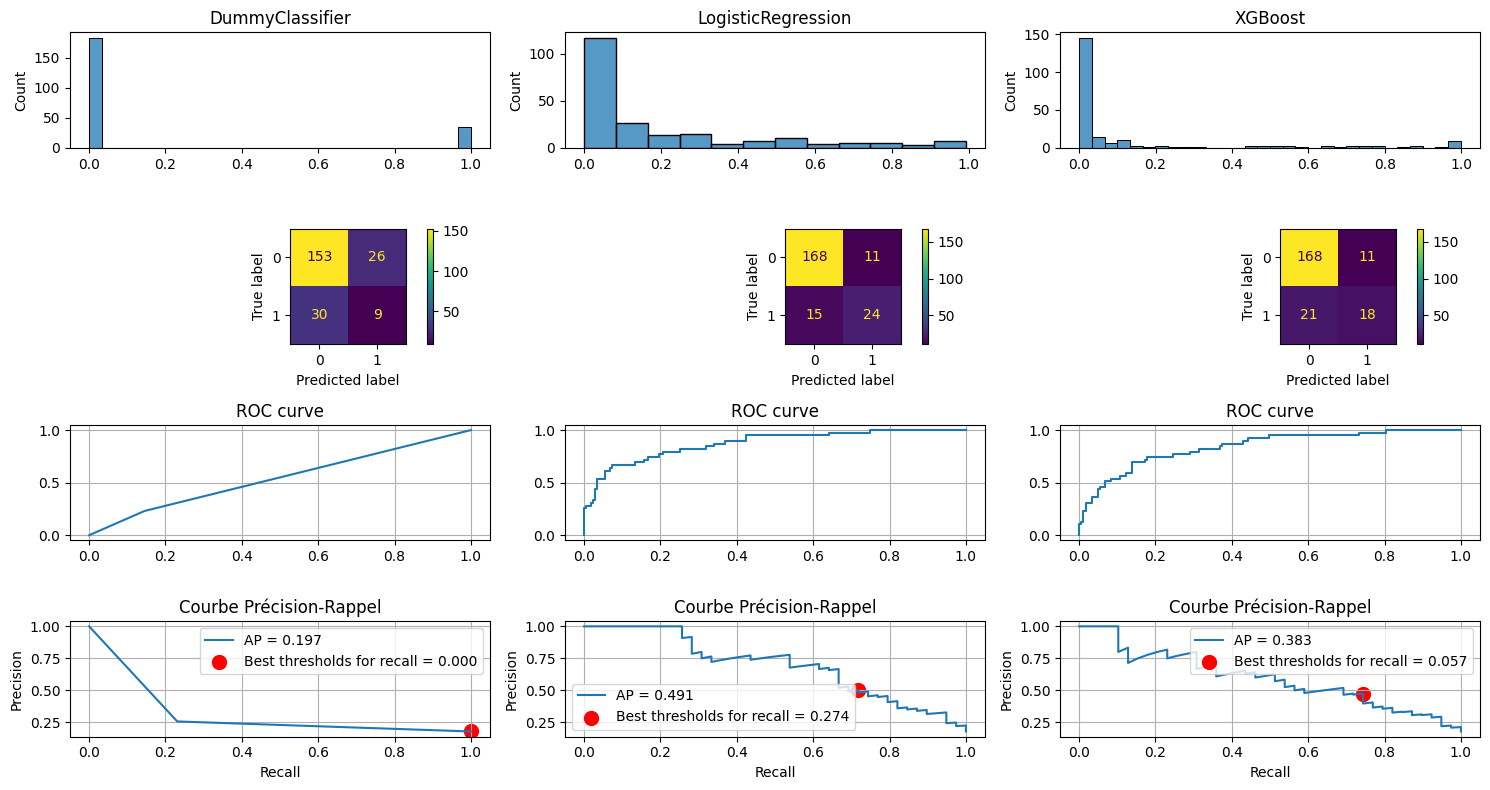

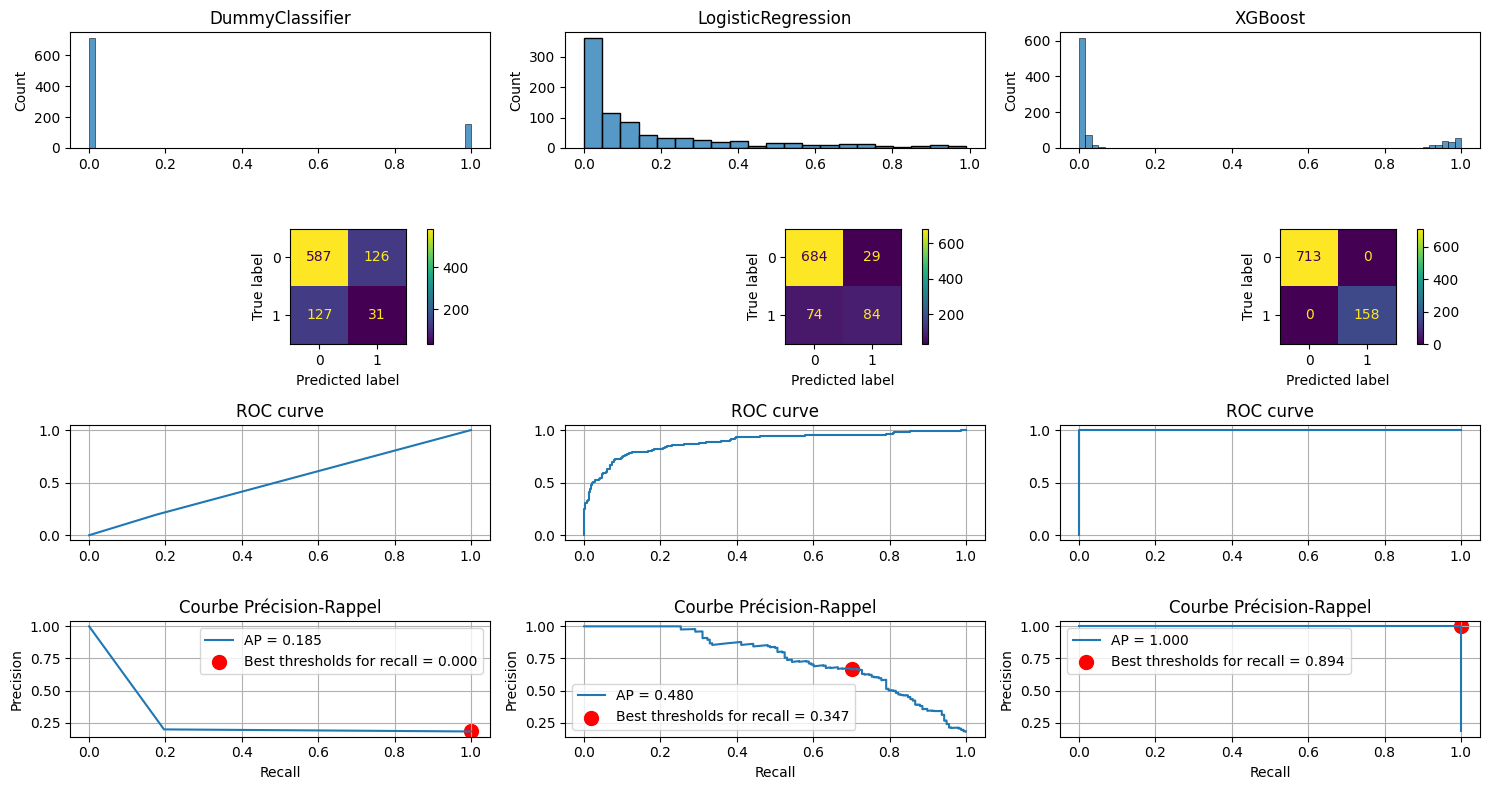

In [1608]:
class InitialTrain(BaseTrain):
    def before(self):
        return None

    def after(self):
        return None

passInst = InitialTrain("Premier entrainement")
passInst.train_and_evaluate()
passInst.print()

## validation croisée

Validation croisée stratifié 'recall'
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.
   Si < 10% de positifs le jeu est mal proportionné
   
StratifiedKFold équilibre les proportions de True/False, si OK, le jeu est bien distribué.

Si non, vérifier:
* modèle XGBoost
* seuil de décision
* qualité des variables explicatives
* surapprentissage ?

In [1609]:
if BaseTrain.threshold["XGBoost"] != 0.5:
    raise RuntimeError("Pour comparer le recall de cross_validate avec le model, ce dernier doit utiliser un seuil de 0.5")

results = cross_validate("XGBoost", BaseTrain.Params["XGBoost"]) # seuil implicite = 0.5

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

print_split_distribution([results | result])

Validation croisée stratifié 'recall'
   Exemple : recall_cross_mean = 0.95, le modèle a un rappel moyen de 95% (capacité à détecter les vrais cas) sur les différentes stratification du jeu de test.
   Il est important de vérifier que la distribution des folds 'strates' dans le jeu d'entrainement n'est pas trop déséquilibré.

XGBoost


,0
recall,0.462
recall_cross_mean,0.367
recall_cross,"[0.375, 0.419, 0.29, 0.406, 0.344]"


,0,1,2,3
0,0.181,0.819,0.183,0.817
1,0.182,0.818,0.178,0.822
2,0.182,0.818,0.178,0.822
3,0.181,0.819,0.184,0.816
4,0.181,0.819,0.184,0.816


classe positive (True) : ~17 %
classe négative (False) : ~83 %

Distribution plutot saine:
* pas de fold sans positifs
* pas de déséquilibre extrême
* stratification globalement correcte

# Feature enginering

Taille du jeu d'entraînement : 871 lignes
Taille du jeu de test : 218 lignes


# PASSE N°2
## FeatureEngineringPass

**Crée de nouvelles features**

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.743,0.257,0.231,0.243,0.543
1,LogisticRegression,0.885,0.719,0.590,0.648,0.870
2,XGBoost,0.872,0.704,0.487,0.576,0.805


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.710,0.197,0.196,0.197,0.510
1,LogisticRegression,0.887,0.788,0.519,0.626,0.886
2,XGBoost,1.000,1.000,1.000,1.000,1.000


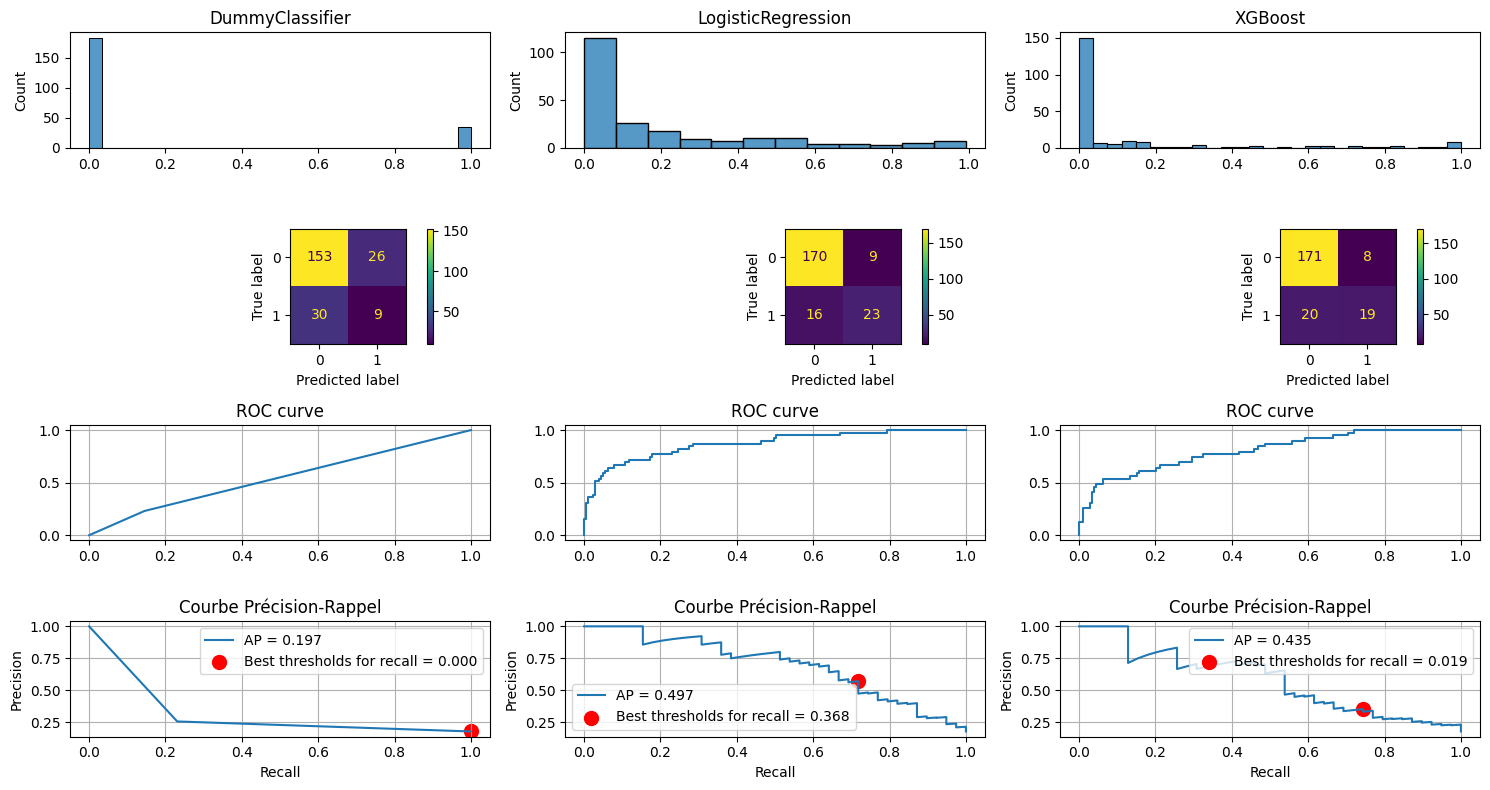

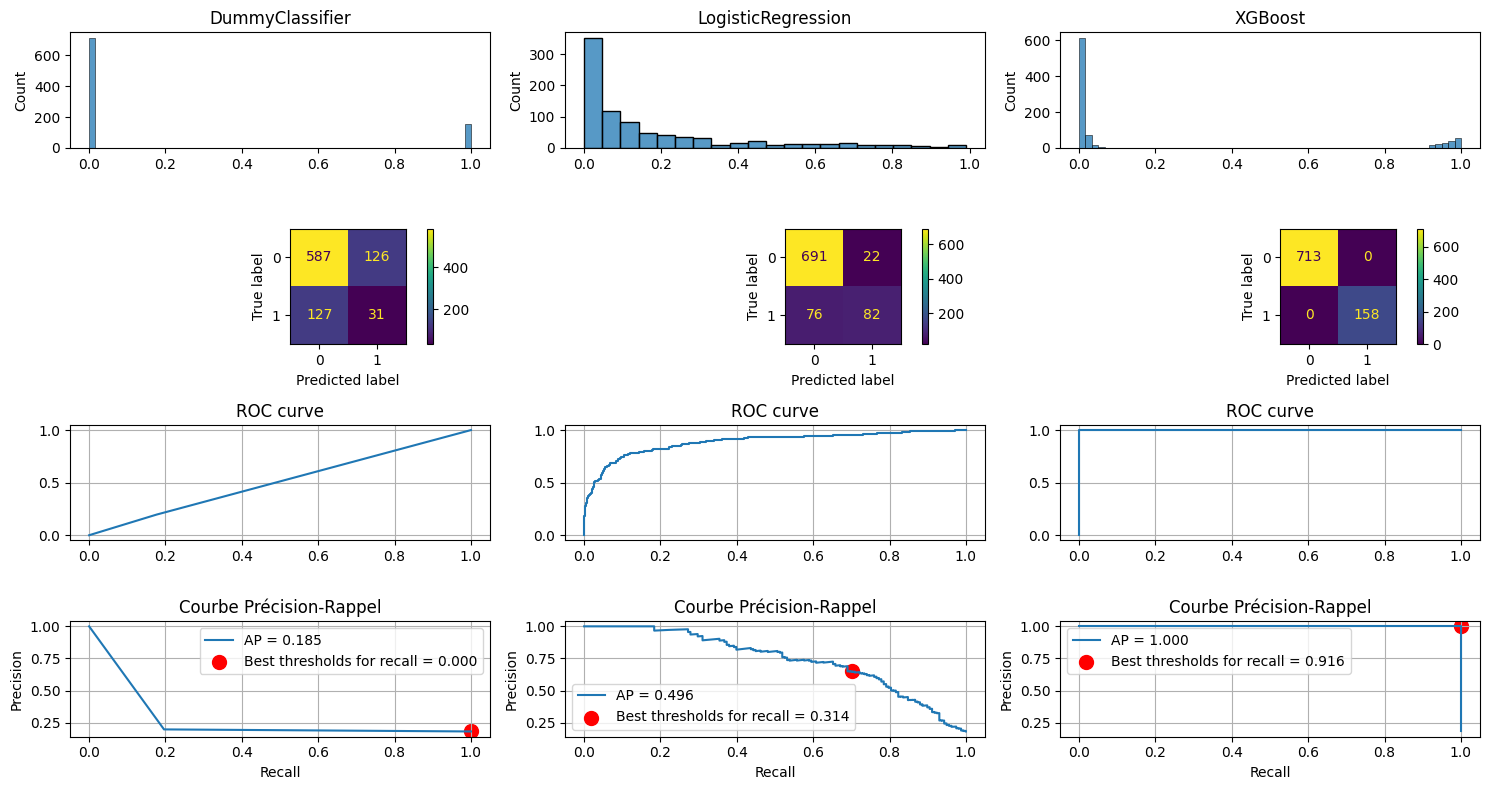

In [1610]:
class FeatureEngineringPass(BaseTrain):
    def before(self):
        global df
        
        # mesure si la personne reste longtemps dans le même poste
        df["anciennete_relative"] = df["annees_dans_l_entreprise"] / (df["annee_experience_totale"] + 1)

        # mesure si la personne reste longtemps dans le même poste
        df["stagnation"] = df["annees_dans_l_entreprise"] - df["annees_dans_le_poste_actuel"]

        # promotion attendue
        df["retard_promotion"] = df["annees_depuis_la_derniere_promotion"] / (df["annees_dans_l_entreprise"]+1)

        # expérience externe vs interne
        df["progression"] = df["annee_experience_totale"] - df["annees_dans_l_entreprise"]

        # détecte sous-rémunération potentielle
        df["salaire_par_annee"] = df["revenu_mensuel"] / (df["annees_dans_l_entreprise"] + 1)

        # Sous-positionnement hiérarchique
        #df["niveau_par_annee"] = df["niveau_hierarchique_poste"] / (df["annees_dans_l_entreprise"] + 1)
        
        df["pression_travail"] = df["heure_supplementaires"] * df["frequence_deplacement"]

        df["satisfaction_globale"] = (
            df["satisfaction_employee_nature_travail"] +
            df["satisfaction_employee_equipe"] +
            df["satisfaction_employee_equilibre_pro_perso"]
        )

        df.drop(columns=[
            #"heure_supplementaires",
            #"nombre_participation_pee",
            #"nb_formations_suivies",
            #"distance_domicile_travail",
            "niveau_education",
            #"frequence_deplacement",
            #"annees_depuis_la_derniere_promotion",
            "annes_sous_responsable_actuel",
            #"age",
            #"revenu_mensuel",
            #"nombre_experiences_precedentes",
            #"annee_experience_totale",
            #"annees_dans_l_entreprise",
            #"annees_dans_le_poste_actuel",
            #"note_evaluation_precedente",
            #"satisfaction_employee_environnement",
            #"satisfaction_employee_nature_travail",
            #"satisfaction_employee_equipe",
            #"satisfaction_employee_equilibre_pro_perso",
            "note_evaluation_actuelle",
            #"heure_supplementaires",
            #"augementation_salaire_precedente_percent",
            #"est_un_homme",
            #"domaine_etude_Entrepreunariat",
            #"domaine_etude_Infra & Cloud",
            #"domaine_etude_Marketing",
            #"domaine_etude_Ressources Humaines",
            #"domaine_etude_Transformation Digitale",
            #"statut_marital_Divorcé(e)",
            "statut_marital_Marié(e)",
            #"departement_Consulting",
            #"departement_Ressources Humaines",
            #"poste_Cadre Commercial",
            #"poste_Consultant",
            #"poste_Directeur Technique",
            #"poste_Manager",
            #"poste_Représentant Commercial",
            #"poste_Ressources Humaines",
            #"poste_Senior Manager",
            #"poste_Tech Lead",
        ], inplace=True)
        
        # on recréer le jeu de données
        separation_train_test()

passInst = FeatureEngineringPass("Crée de nouvelles features")
passInst.train_and_evaluate()
passInst.print()

# Overfit

* Le modèle XGBoost présente un fort Sur-apprentissage sur le jeu d'entrainement F1-score 0.98 / 0.42
* Le modèle LogisticRegression est moins affecté par le Sur-apprentissage 0.48 / 0.58
* Les modèles restent meilleur que le dummy de référence


Remédiations:
* Vérifier la qualité du découpage entraînement / test => contrôler les doublons d’ID ou les chevauchements de groupes entre train et test ou split par groupe plutôt qu’un split aléatoire
* Vérifier la présence de fuite de données dans les variables explicatives => revue des features et de leur mode de calcul est souvent nécessaire, en particulier pour les agrégations
* Une complexité excessive du modèle par rapport à la quantité de données => la régularisation, la réduction de profondeur, le subsampling des lignes et des colonnes permettent de forcer une généralisation plus robuste

# Vérifie la répartition des données train/test

In [1611]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
0    0.8191
1    0.1809
Name: proportion, dtype: float64

In [1612]:
y_train.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.818599
1    0.181401
Name: proportion, dtype: float64

In [1613]:
y_test.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.821101
1    0.178899
Name: proportion, dtype: float64

La répartition true / false est plutot bien répartie



Dans ce type de situation (ex : démissions rares), XGBoost peut privilégier fortement la classe majoritaire.

Résultat :

prédictions quasi toujours négatives
donc faux négatifs élevés
rappel très faible voire nul sur certains folds

# optimisation des hyperparamètres

197 892 4.527918781725888


# PASSE N°3
## ScaleParamsPass

**Gestion du déséquilibre : démission/en place**

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.743,0.257,0.231,0.243,0.543
1,LogisticRegression,0.885,0.719,0.590,0.648,0.870
2,XGBoost,0.853,0.621,0.462,0.529,0.793


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.710,0.197,0.196,0.197,0.510
1,LogisticRegression,0.887,0.788,0.519,0.626,0.886
2,XGBoost,1.000,1.000,1.000,1.000,1.000


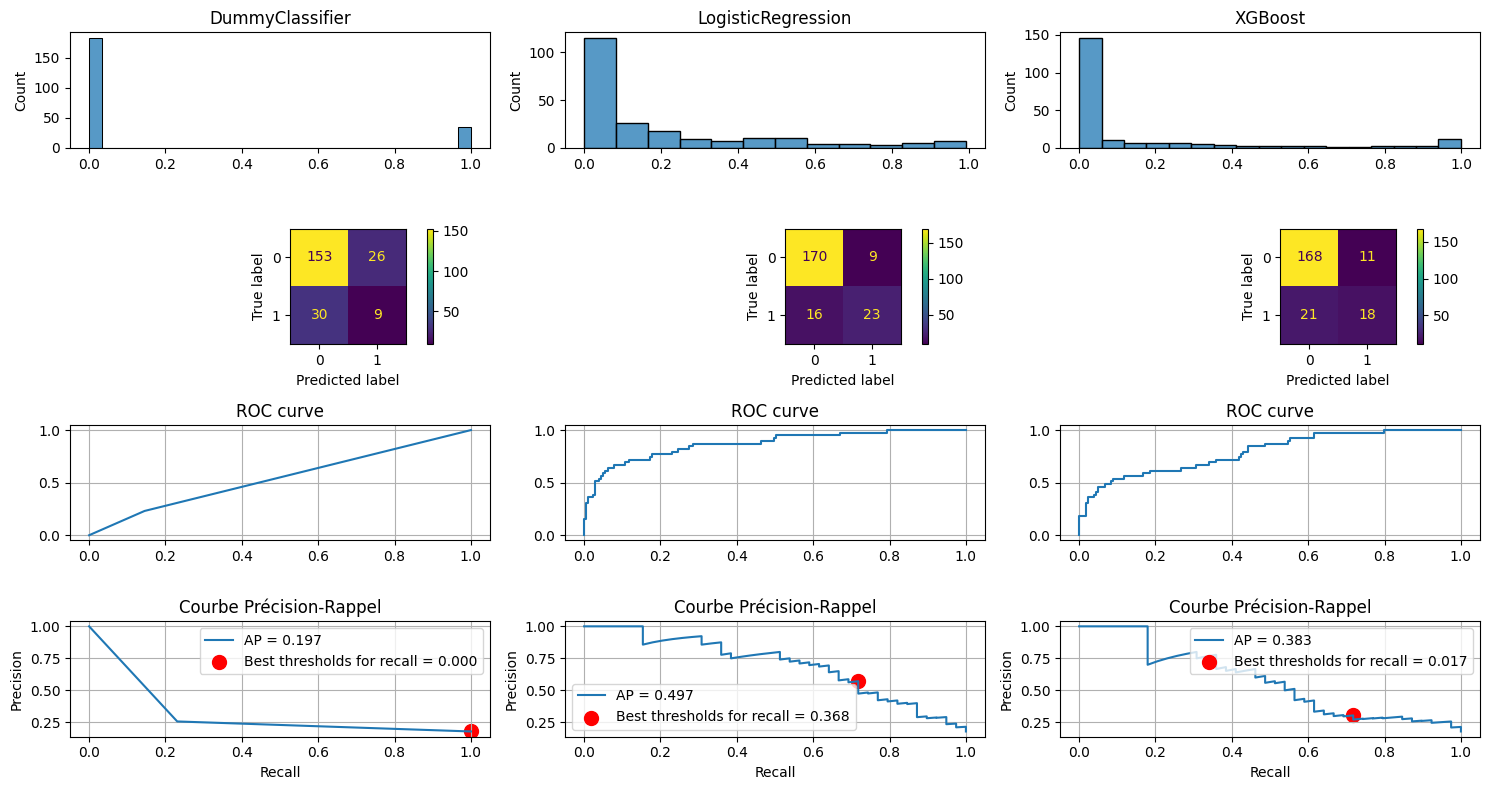

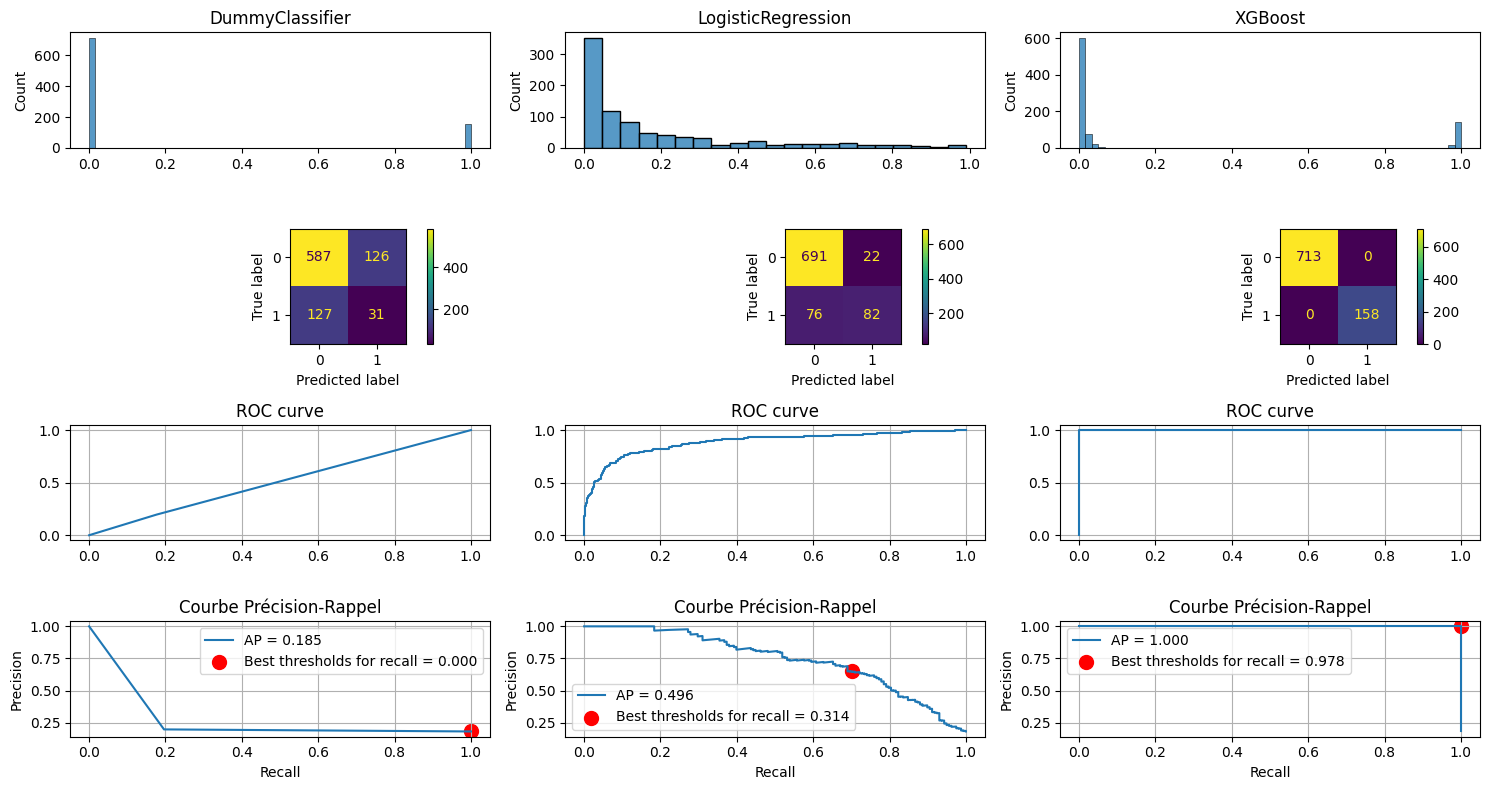

In [1614]:
class ScaleParamsPass(BaseTrain):
    def before(self):
        BaseTrain.Params["RandomForestClassifier"]["class_weight"] = "balanced"

        # equilibre le poids 
        nb_pos = (df["a_quitte_l_entreprise"] == True).sum()
        nb_neg = (df["a_quitte_l_entreprise"] == False).sum()
        BaseTrain.Params["XGBoost"]["scale_pos_weight"] = nb_neg / nb_pos
        print(nb_pos, nb_neg, BaseTrain.Params["XGBoost"]["scale_pos_weight"])

passInst = ScaleParamsPass("Gestion du déséquilibre : démission/en place")
passInst.train_and_evaluate()
passInst.print()

# recherche des hyperparamètres

In [1615]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

model = XGBClassifier()

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [100, 300],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "reg_lambda": [1, 5],
    "reg_alpha": [0, 1],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

display(grid.best_score_)

display(grid.best_params_)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


np.float64(0.5458447322642214)

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 300,
 'reg_alpha': 0,
 'reg_lambda': 5,
 'subsample': 0.8}

# PASSE N°4
## HyperParamsPass

**Ajuste les hyper paramètres de XGBoost**

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.743,0.257,0.231,0.243,0.543
1,LogisticRegression,0.885,0.719,0.590,0.648,0.870
2,XGBoost,0.835,0.529,0.692,0.600,0.833


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.710,0.197,0.196,0.197,0.510
1,LogisticRegression,0.887,0.788,0.519,0.626,0.886
2,XGBoost,0.940,0.768,0.962,0.854,0.993


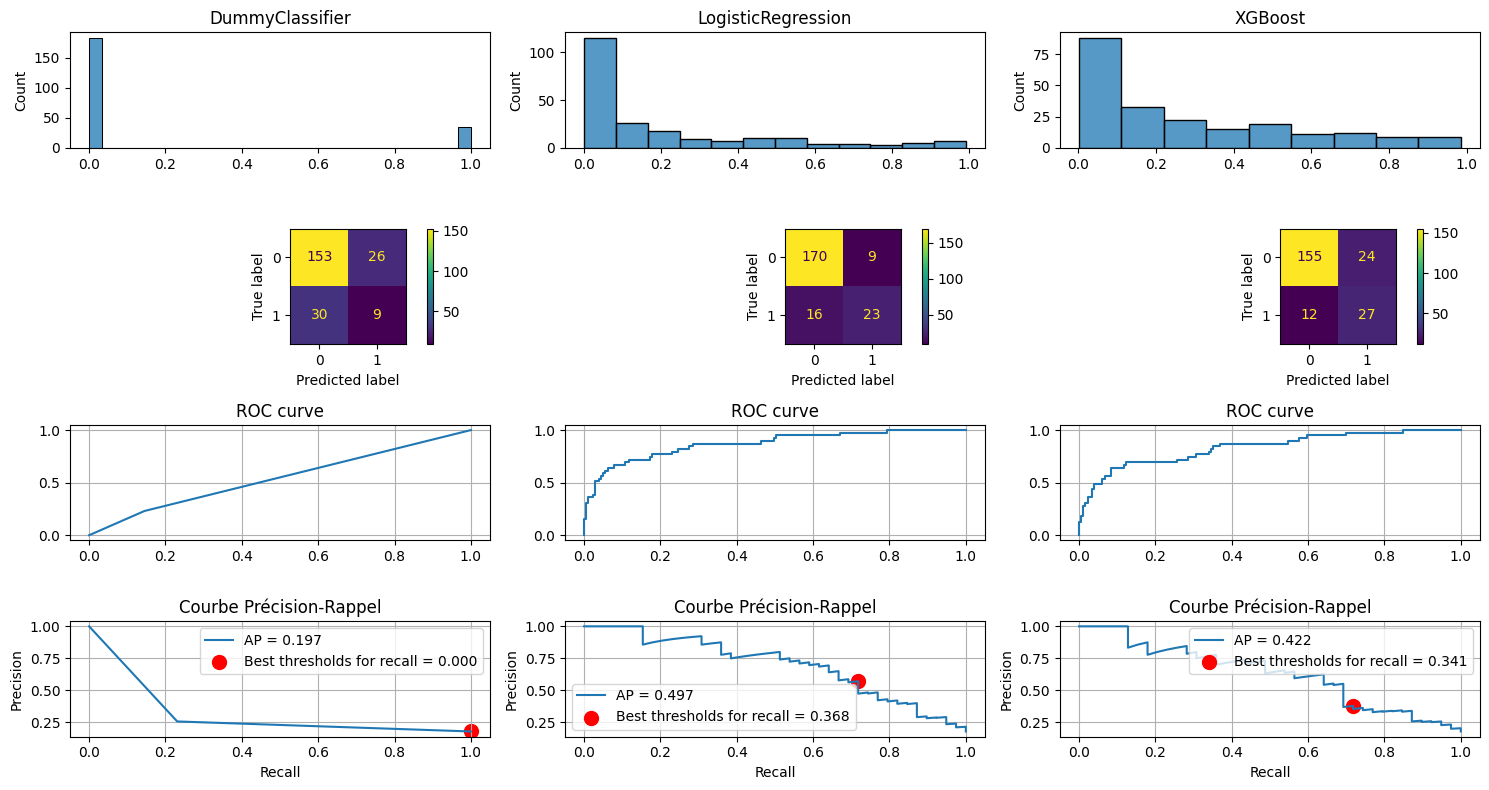

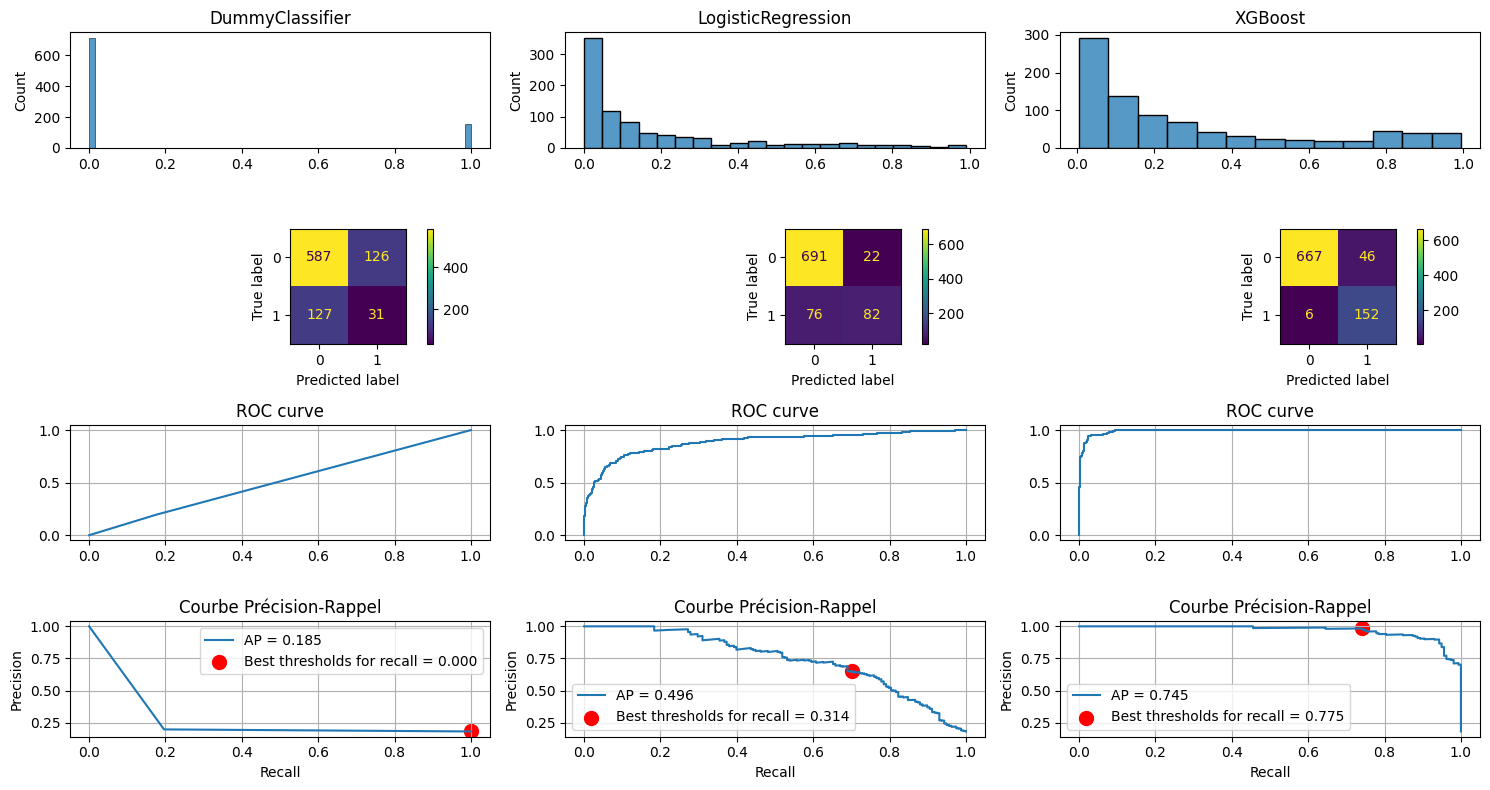

In [1616]:
class HyperParamsPass(BaseTrain):
    def before(self):
        BaseTrain.Params["XGBoost"]["max_depth"] = 3
        BaseTrain.Params["XGBoost"]["n_estimators"] = 300
        BaseTrain.Params["XGBoost"]["reg_lambda"] = 5
        BaseTrain.Params["XGBoost"]["reg_alpha"] = 1
        BaseTrain.Params["XGBoost"]["subsample"] = 0.8
        BaseTrain.Params["XGBoost"]["min_child_weight"] = 5
        BaseTrain.Params["XGBoost"]["learning_rate"] = 0.05

passInst = HyperParamsPass("Ajuste les hyper paramètres de XGBoost")
passInst.train_and_evaluate()
passInst.print()

# recherche du meilleur seuil (XGBoost)

DummyClassifier Best threshold: 0.1
DummyClassifier Best F1: 0.24324324324324326
LogisticRegression Best threshold: 0.5
LogisticRegression Best F1: 0.647887323943662
XGBoost Best threshold: 0.5
XGBoost Best F1: 0.6


# PASSE N°5
## ThresholdPass

**Ajuste le seuil de décision en fonction du meilleur F1-score**

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   La probabilité que le modèle attribue un score plus élevé à un positif qu’à un négatif
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.743,0.257,0.231,0.243,0.543
1,LogisticRegression,0.885,0.719,0.590,0.648,0.870
2,XGBoost,0.835,0.529,0.692,0.600,0.833


,model,accuracy,precision,recall,f1,auc
0,DummyClassifier,0.710,0.197,0.196,0.197,0.510
1,LogisticRegression,0.887,0.788,0.519,0.626,0.886
2,XGBoost,0.940,0.768,0.962,0.854,0.993


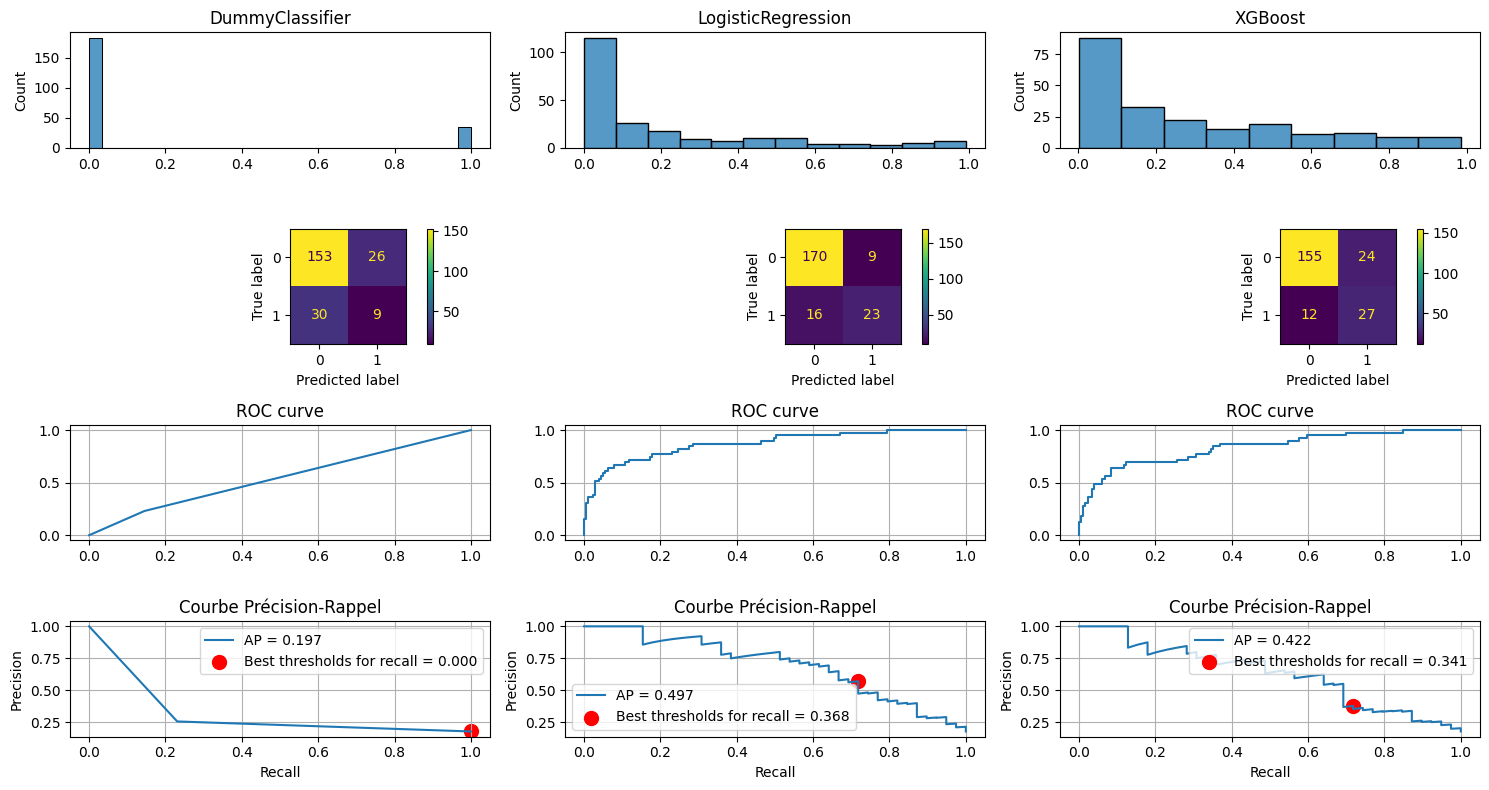

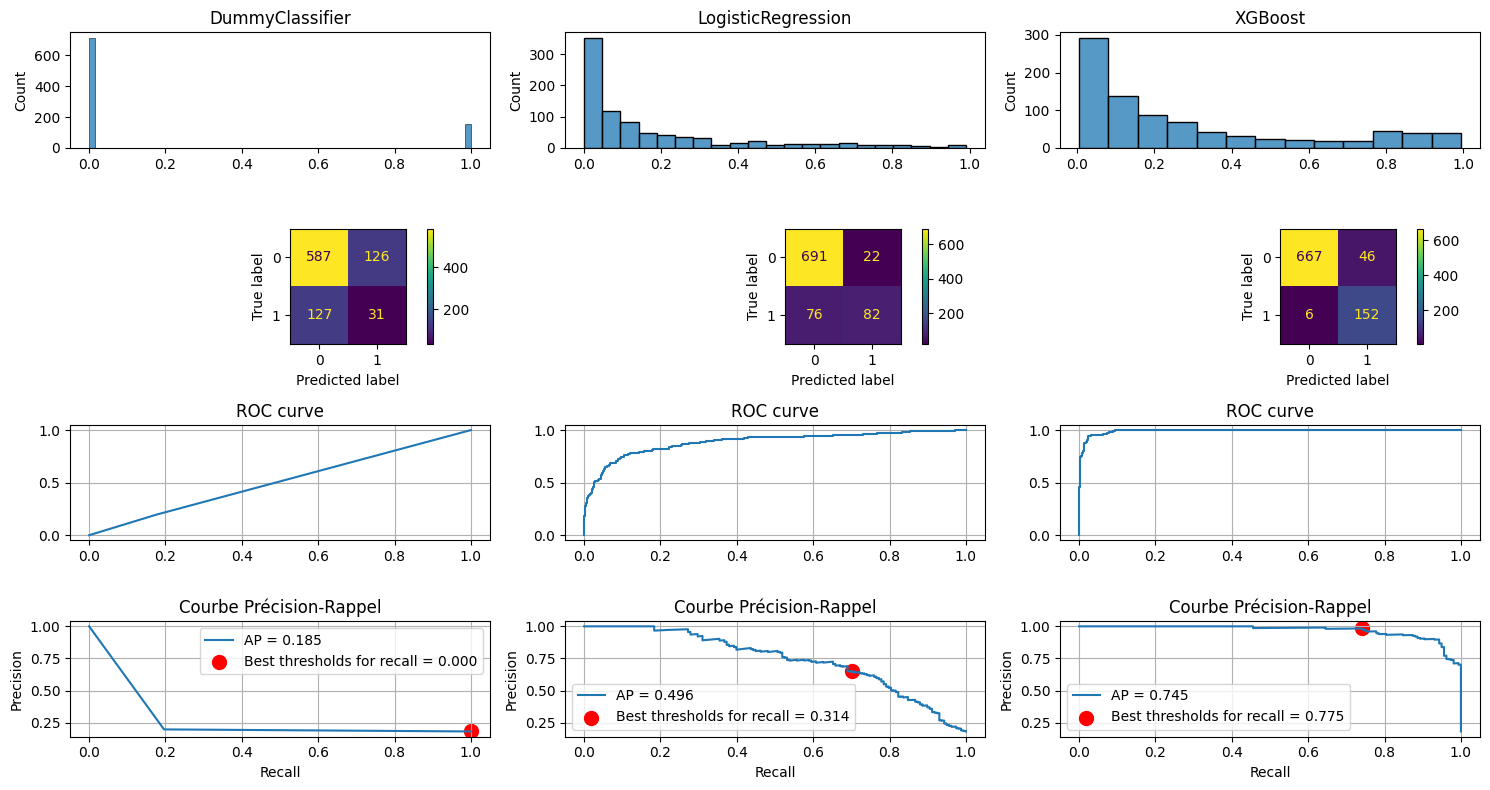

In [1617]:
class ThresholdPass(BaseTrain):

    def before(self):
                
        # noms des modèles (pris sur la première passe)
        models = [r["model"] for r in BaseTrain.pass_list[0]]

        for model in models:
            best_t, best_f1 = 0, 0

            for t in range(1, 9, 1):
                threshold = 0.1 * t
                results = entrainement_model(model, BaseTrain.Params[model], threshold, True)

                f1 = results["f1"]
                    
                if f1 > best_f1:
                    best_f1 = f1
                    best_t = threshold

            print(model, "Best threshold:", best_t)

            print(model, "Best F1:", best_f1)

            BaseTrain.threshold[model] = best_t
        

passInst = ThresholdPass("Ajuste le seuil de décision en fonction du meilleur F1-score")
passInst.train_and_evaluate()
passInst.print()

In [1618]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,int64
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,frequence_deplacement,int64
5,annees_depuis_la_derniere_promotion,int64
6,age,int64
7,revenu_mensuel,int64
8,nombre_experiences_precedentes,int64
9,annee_experience_totale,int64


# Export

In [1619]:
df.to_parquet("model.parquet")

# Affiche un graphique de l'évolution du F1-score

In [1620]:
display(BaseTrain.Params["XGBoost"])

{'n_estimators': 300,
 'max_depth': 3,
 'eval_metric': 'logloss',
 'enable_categorical': True,
 'scale_pos_weight': np.float64(4.527918781725888),
 'reg_lambda': 5,
 'reg_alpha': 1,
 'subsample': 0.8,
 'min_child_weight': 5,
 'learning_rate': 0.05}

DummyClassifier
[0.24324324 0.24324324 0.24324324 0.24324324 0.24324324]
LogisticRegression
[0.64864865 0.64788732 0.64788732 0.64788732 0.64788732]
XGBoost
[0.52941176 0.57575758 0.52941176 0.6        0.6       ]


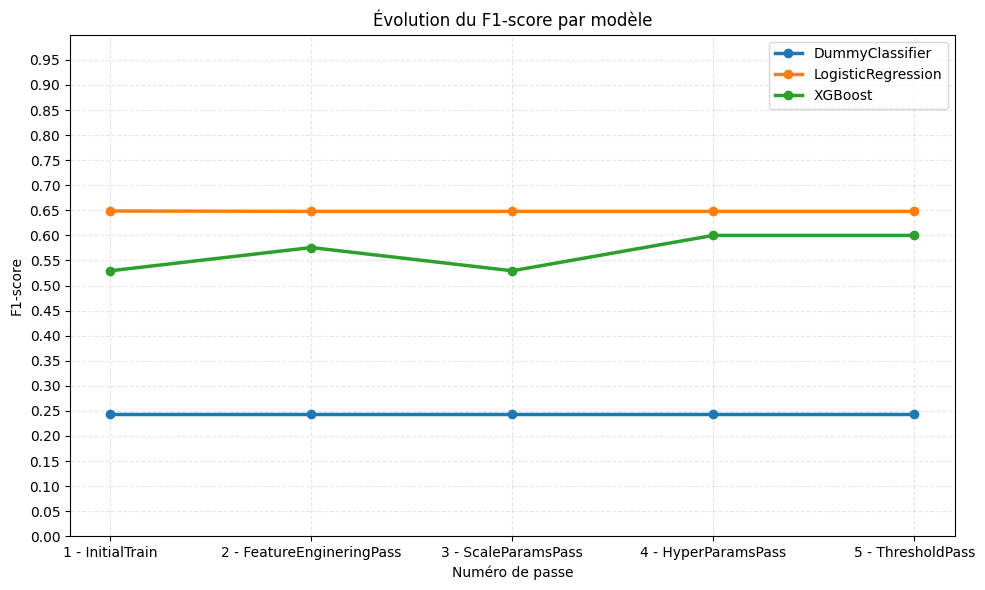

In [1621]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in BaseTrain.pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(BaseTrain.pass_list), len(models)))

j = 0
for results_list in BaseTrain.pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["f1"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, len(BaseTrain.pass_list)+1, 1)  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    print(models[i])
    print(f1_scores)
    
    i += 1


ax.set_ylim(0, 1)
ax.set_title("Évolution du F1-score par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("F1-score")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()


labels_avec_numero = [f"{i+1} - {label}" for i, label in enumerate(BaseTrain.pass_names)]
plt.xticks(x, labels_avec_numero)
plt.yticks(np.arange(0, 1, 0.05))
plt.tight_layout()
plt.show()

DummyClassifier
[0.23076923 0.23076923 0.23076923 0.23076923 0.23076923]
LogisticRegression
[0.61538462 0.58974359 0.58974359 0.58974359 0.58974359]
XGBoost
[0.46153846 0.48717949 0.46153846 0.69230769 0.69230769]


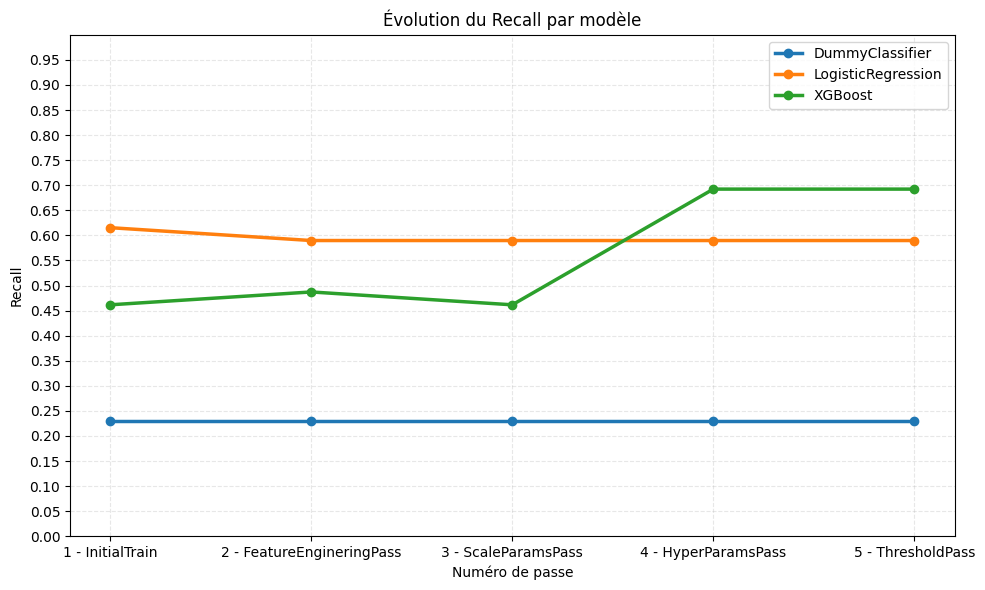

In [1622]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in BaseTrain.pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(BaseTrain.pass_list), len(models)))

j = 0
for results_list in BaseTrain.pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["recall"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, len(BaseTrain.pass_list)+1, 1)  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    print(models[i])
    print(f1_scores)
    
    i += 1


ax.set_ylim(0, 1)
ax.set_title("Évolution du Recall par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("Recall")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()


labels_avec_numero = [f"{i+1} - {label}" for i, label in enumerate(BaseTrain.pass_names)]
plt.xticks(x, labels_avec_numero)
plt.yticks(np.arange(0, 1, 0.05))
plt.tight_layout()
plt.show()

# Comparaison des départs réel et prédit en fonction du poste
Permet de confirmer si l'analyse exploratoire dit juste

In [1623]:
df_original.groupby("poste")["a_quitte_l_entreprise"] \
  .mean() \
  .sort_values(ascending=False)

poste
Représentant Commercial    0.397590
Consultant                 0.239382
Ressources Humaines        0.212766
Assistant de Direction     0.161512
Cadre Commercial           0.153509
Tech Lead                  0.061856
Manager                    0.047619
Name: a_quitte_l_entreprise, dtype: float64

In [1624]:
df_pred = X_test.copy()

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

df_pred["poste"] = df_original.loc[X_test.index, "poste"]

df_pred["proba_depart"] = result["y_proba"]
df_pred["depart_reel"] = result["y"]

df_pred.groupby("poste")["proba_depart"] \
       .mean() \
       .sort_values(ascending=False)

poste
Représentant Commercial    0.557490
Ressources Humaines        0.441205
Consultant                 0.354753
Assistant de Direction     0.242494
Cadre Commercial           0.231119
Manager                    0.189987
Tech Lead                  0.114578
Name: proba_depart, dtype: float32

# visualisation des features importances globales

In [1625]:
import shap

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

# calcul des SHAP values
explainer = shap.TreeExplainer(result["clf"])

shap_values = explainer.shap_values(X_test)

# Moyenne de l'importance absolue des SHAP values par variable
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="importance",
    ascending=False
)

print(shap_importance.head(10))

                                feature  importance
0              nombre_participation_pee    0.523360
17                heure_supplementaires    0.479078
39                     pression_travail    0.395372
6                        revenu_mensuel    0.369371
40                 satisfaction_globale    0.317112
2             distance_domicile_travail    0.309969
11  satisfaction_employee_environnement    0.309263
5                                   age    0.282118
7        nombre_experiences_precedentes    0.271848
34                  anciennete_relative    0.267840


## Beeswarm SHAP (importance globale)

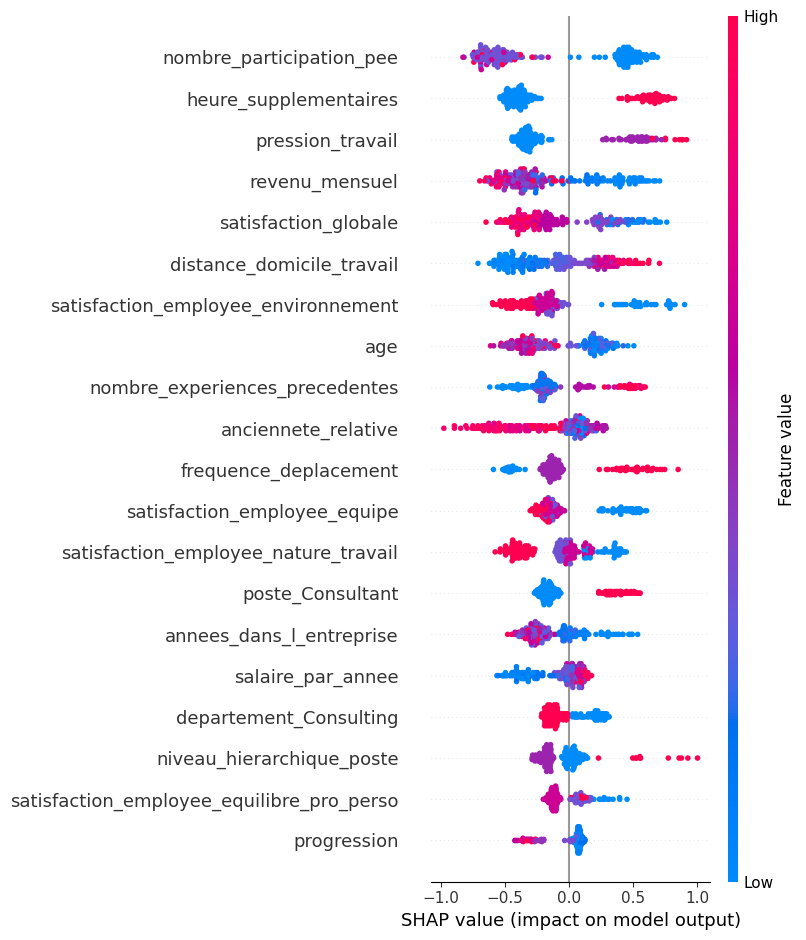

In [1626]:
shap.summary_plot(shap_values, X_test)

## SHAP scatter plots colorés

In [1627]:
df["distance_domicile_travail"].describe()

count    1089.000000
mean        9.150597
std         8.040757
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: distance_domicile_travail, dtype: float64

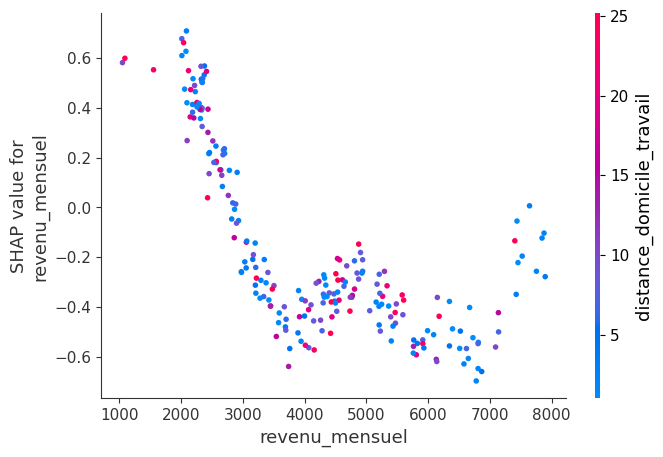

In [1628]:
shap.dependence_plot(
    "revenu_mensuel",
    shap_values,
    X_test,
    interaction_index="distance_domicile_travail"
)

In [1629]:
df["satisfaction_globale"].describe()

count    1089.000000
mean        8.180900
std         1.698659
min         3.000000
25%         7.000000
50%         8.000000
75%         9.000000
max        12.000000
Name: satisfaction_globale, dtype: float64

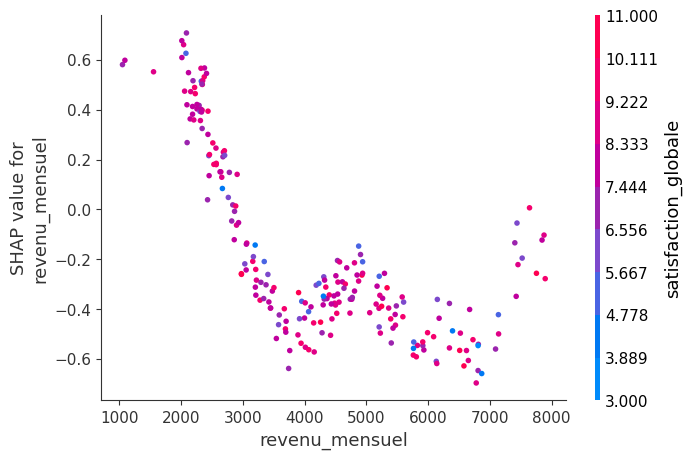

In [1630]:
shap.dependence_plot(
    "revenu_mensuel",
    shap_values,
    X_test,
    interaction_index="satisfaction_globale"
)

## waterfall plots

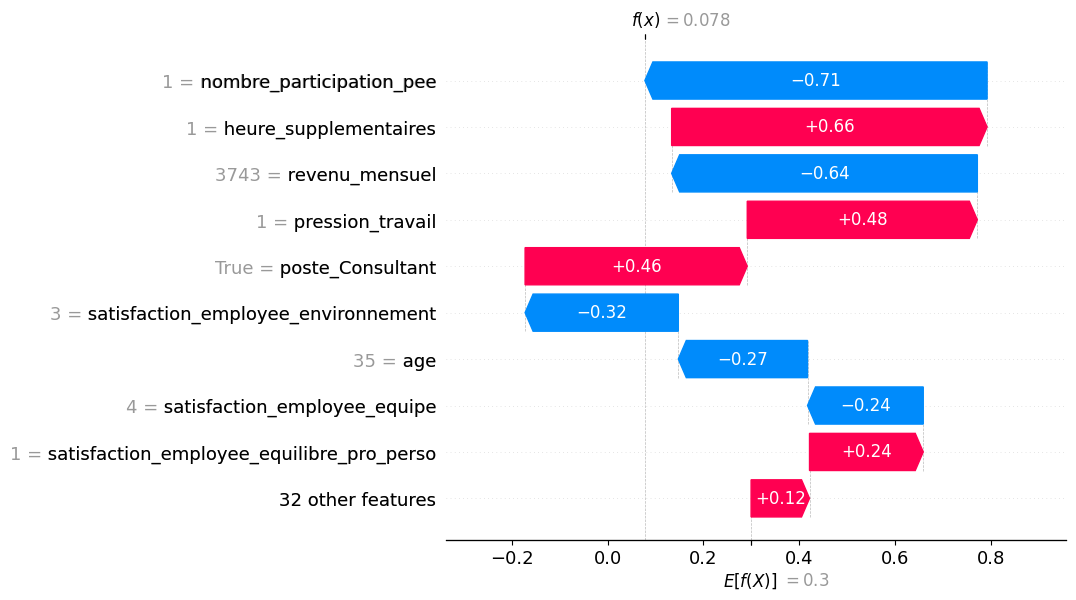

In [1631]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1],
        base_values=explainer.expected_value,
        data=X_test.iloc[1],
        feature_names=X_test.columns
    )
)

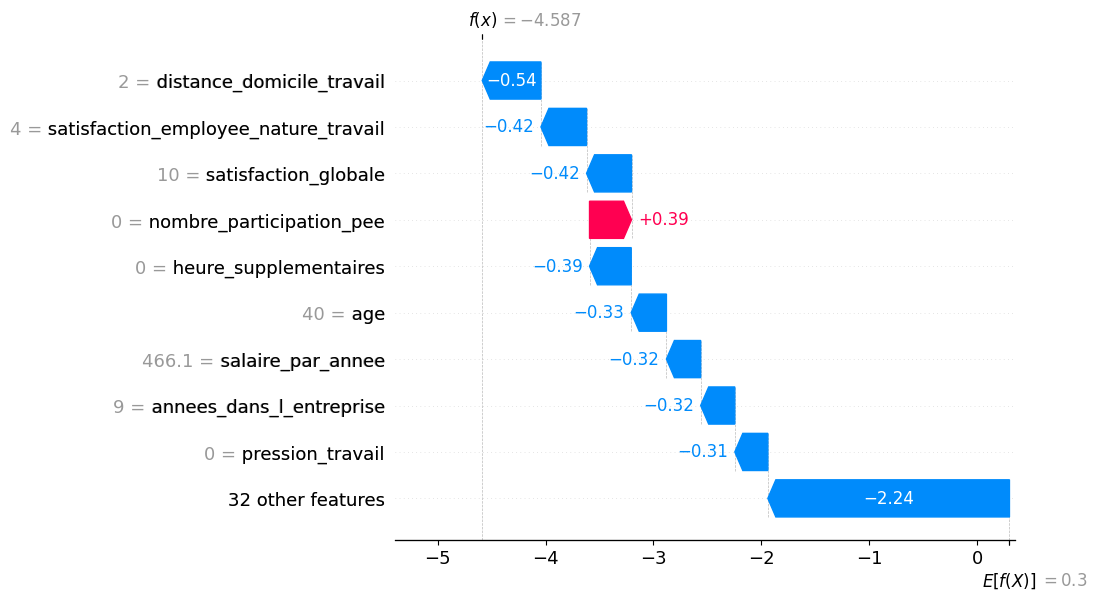

In [1632]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[10],
        base_values=explainer.expected_value,
        data=X_test.iloc[10],
        feature_names=X_test.columns
    )
)

In [1633]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = next((x for x in passInst.results_list if x["model"] == "XGBoost"), None)

perm_importance = permutation_importance(
    result["clf"],
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean
}).sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(10))

                                 feature  importance
2              distance_domicile_travail    0.030734
5                                    age    0.021560
17                 heure_supplementaires    0.020642
34                   anciennete_relative    0.016514
0               nombre_participation_pee    0.015138
7         nombre_experiences_precedentes    0.014679
8                annee_experience_totale    0.014220
14  satisfaction_employee_nature_travail    0.011927
6                         revenu_mensuel    0.010092
26                departement_Consulting    0.009174


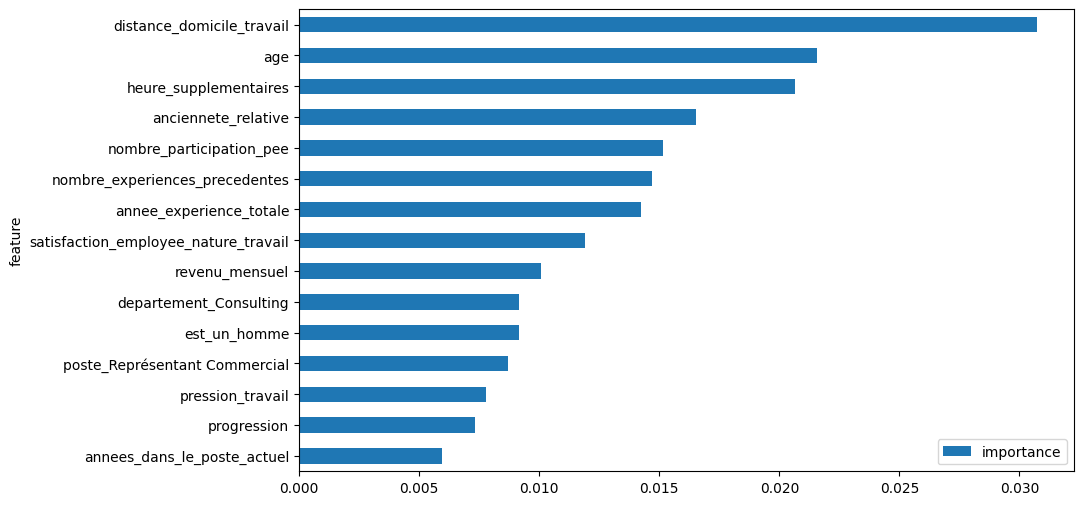

In [1634]:
importance_df.head(15).plot.barh(
    x="feature",
    y="importance",
    figsize=(10, 6)
)
plt.gca().invert_yaxis()
plt.show()

Ce graphique répond à la question suivante:
    >> quels facteurs poussent un employé à partir ou rester, et dans quel sens ?

* Les heures supplémentaires (bool) sont parfaitement séparées, elle pèse beaucoup dans la prédiction de quitter l'entreprise => se confirme avec l'exploration des données
* Les revenu pèses aussi beaucoup, les hauts revenus ont bien plus tendance à rester que l'inverse => se confirme avec l'exploration des données 
* Le nombre de participations est également assez tranché, tous les départs ont eu peu de participations =>  se confirme avec l'exploration des données 
* Globalement la satisfaction joue un role
* les déplacements sont aussi tranché malgré une base mixte

In [1635]:
# Création de l'objet DiCE

import dice_ml

df = df.astype(int)

separation_train_test()

result = entrainement_model("XGBoost", BaseTrain.Params["XGBoost"], BaseTrain.threshold["XGBoost"], True)

model = result["clf"]

# DataFrame utilisé par le modèle
df_dice = X.copy()

df_dice["a_quitte_l_entreprise"] = y

continuous_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

data_dice = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=continuous_features,
    outcome_name="a_quitte_l_entreprise"
)

model_dice = dice_ml.Model(
    model=model,
    backend="sklearn"
)

exp = dice_ml.Dice(
    data_dice,
    model_dice,
    method="random"
)

Taille du jeu d'entraînement : 871 lignes
Taille du jeu de test : 218 lignes


In [1636]:
# Employé "partant" utilisé pour le test

employee = X_test.iloc[[2]]

employee.T

,1236
nombre_participation_pee,3
nb_formations_suivies,3
distance_domicile_travail,13
frequence_deplacement,1
annees_depuis_la_derniere_promotion,2
age,36
revenu_mensuel,6134
nombre_experiences_precedentes,5
annee_experience_totale,16
annees_dans_l_entreprise,2


In [1637]:
y_test.iloc[[2]]

1236    1
Name: a_quitte_l_entreprise, dtype: int64

In [1638]:

print(employee.dtypes)
print(employee.shape)

nombre_participation_pee                     int64
nb_formations_suivies                        int64
distance_domicile_travail                    int64
frequence_deplacement                        int64
annees_depuis_la_derniere_promotion          int64
age                                          int64
revenu_mensuel                               int64
nombre_experiences_precedentes               int64
annee_experience_totale                      int64
annees_dans_l_entreprise                     int64
annees_dans_le_poste_actuel                  int64
satisfaction_employee_environnement          int64
note_evaluation_precedente                   int64
niveau_hierarchique_poste                    int64
satisfaction_employee_nature_travail         int64
satisfaction_employee_equipe                 int64
satisfaction_employee_equilibre_pro_perso    int64
heure_supplementaires                        int64
augementation_salaire_precedente             int64
est_un_homme                   

In [1639]:
model.predict_proba(employee)

array([[0.65666544, 0.34333456]], dtype=float32)

In [1640]:
risky_employees = X_test.copy()

risky_employees["risk"] = model.predict_proba(X_test)[:,1] # réalise les prédictions

risky_employees = risky_employees.sort_values( # tri pour obtenir ayant le plus haut taux de valeur fortes (1 = quitte l'entreprise)
    "risk",
    ascending=False
).head(20)

risky_employees

,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,frequence_deplacement,annees_depuis_la_derniere_promotion,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,heure_supplementaires,augementation_salaire_precedente,est_un_homme,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,statut_marital_Divorcé(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Tech Lead,anciennete_relative,stagnation,retard_promotion,progression,salaire_par_annee,pression_travail,satisfaction_globale,risk
1060,0,2,9,2,0,24,3172,2,4,0,0,2,3,1,1,3,2,1,11,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,4,3172,2,6,0.985193
463,0,3,24,1,0,26,2340,1,1,1,0,3,1,1,4,2,1,1,18,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1170,1,7,0.982807
688,0,3,21,1,0,19,2121,1,1,1,0,4,2,1,2,2,4,1,13,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1060,1,8,0.975986
1365,0,3,24,2,0,29,1091,1,1,1,0,3,4,1,1,4,3,0,17,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,545,0,8,0.952428
1057,0,4,13,2,0,29,5765,5,7,5,3,1,3,2,2,1,1,0,11,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,0,2,960,0,4,0.950478
776,0,3,9,2,0,20,2323,1,2,2,2,4,3,1,4,2,3,1,14,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,774,2,9,0.949148
683,3,2,19,1,0,25,2413,1,1,1,0,3,2,1,2,3,3,1,18,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1206,1,8,0.940644
1436,0,6,5,1,1,21,2380,1,2,2,2,3,3,1,1,4,3,1,11,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,793,1,8,0.920066
856,0,2,3,1,1,20,3033,1,2,2,2,1,2,1,3,1,2,0,12,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1011,0,6,0.908508
1262,1,4,17,2,0,43,2437,9,6,1,0,3,2,1,3,4,3,1,16,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,5,1218,2,10,0.894114


In [1641]:
df.groupby("a_quitte_l_entreprise")["revenu_mensuel"].mean()

a_quitte_l_entreprise
0    4269.512332
1    3418.081218
Name: revenu_mensuel, dtype: float64

In [1642]:
df["revenu_mensuel"].min()

np.int64(1009)

In [1643]:
df["revenu_mensuel"].max()

np.int64(7991)

In [1644]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(10)

,feature,importance
17,heure_supplementaires,0.081827
39,pression_travail,0.054871
13,niveau_hierarchique_poste,0.054729
0,nombre_participation_pee,0.050934
9,annees_dans_l_entreprise,0.044712
40,satisfaction_globale,0.043292
28,poste_Cadre Commercial,0.042877
8,annee_experience_totale,0.034458
31,poste_Représentant Commercial,0.031226
5,age,0.030388


In [1645]:
results = []

permitted_range = {
    "revenu_mensuel": [
        df["revenu_mensuel"].min(),
        df["revenu_mensuel"].max()
    ],
    "frequence_deplacement": [
        df["frequence_deplacement"].min(),
        df["frequence_deplacement"].max()
    ],
    "heure_supplementaires": [0, 1],
    "distance_domicile_travail": [
        0,
        df["distance_domicile_travail"].max()
    ]
}

for idx in risky_employees.index:

    employee = X.loc[[idx]]

    cf = exp.generate_counterfactuals(
        employee,
        total_CFs=1,
        desired_class=0, # prédiction souhaité, 0 = reste
        features_to_vary=[
            "nombre_participation_pee",
            "distance_domicile_travail",
            "frequence_deplacement",
            "revenu_mensuel",
            "heure_supplementaires",
            "satisfaction_employee_nature_travail",
            "satisfaction_employee_equipe",
            "satisfaction_employee_equilibre_pro_perso",
            "note_evaluation_precedente",
            "nombre_experiences_precedentes"
        ],
        permitted_range=permitted_range
    )


    original = employee.iloc[0]
    suggested = cf.cf_examples_list[0].final_cfs_df.iloc[0]

    results.append({
        "employee_id": idx,
        "nombre_participation_pee_change":
            suggested["nombre_participation_pee"] - original["nombre_participation_pee"],
        "distance_domicile_travail_change":
            suggested["distance_domicile_travail"] - original["distance_domicile_travail"],
        "frequence_deplacement_change":
            suggested["frequence_deplacement"] - original["frequence_deplacement"],
        "revenu_change":
            suggested["revenu_mensuel"] - original["revenu_mensuel"],
        "heure_supplementaires_change":
            suggested["heure_supplementaires"] - original["heure_supplementaires"],
    })

report = pd.DataFrame(results)

report

100%|██████████| 1/1 [00:00<00:00,  1.78it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.

In [ ]:
counterfactuals = exp.generate_counterfactuals(
    employee,
    total_CFs=5,
    desired_class=0,
    features_to_vary=[
        "nombre_participation_pee",
        "distance_domicile_travail",
        "frequence_deplacement",
        "revenu_mensuel",
        "heure_supplementaires",
        "satisfaction_employee_nature_travail",
        "satisfaction_employee_equipe",
        "satisfaction_employee_equilibre_pro_perso",
        "note_evaluation_precedente",
        "nombre_experiences_precedentes"
    ]
)

100%|██████████| 1/1 [00:00<00:00,  4.15it/s]


In [ ]:
counterfactuals.visualize_as_dataframe()

Query instance (original outcome : 1)


,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,frequence_deplacement,annees_depuis_la_derniere_promotion,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,heure_supplementaires,augementation_salaire_precedente,est_un_homme,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,statut_marital_Divorcé(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Tech Lead,anciennete_relative,stagnation,retard_promotion,progression,salaire_par_annee,pression_travail,satisfaction_globale,a_quitte_l_entreprise
0,1,2,23,1,0,26,4157,7,5,2,2,3,2,2,4,3,2,1,19,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,1385,1,9,1



Diverse Counterfactual set (new outcome: 0)


,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,frequence_deplacement,annees_depuis_la_derniere_promotion,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,heure_supplementaires,augementation_salaire_precedente,est_un_homme,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,statut_marital_Divorcé(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Tech Lead,anciennete_relative,stagnation,retard_promotion,progression,salaire_par_annee,pression_travail,satisfaction_globale,a_quitte_l_entreprise
0,1,2,5,1,0,26,4157,4,5,2,2,3,2,2,4,3,2,1,19,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,1385,1,9,0
1,1,2,23,1,0,26,4157,4,5,2,2,3,2,2,4,3,2,0,19,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,1385,1,9,0
2,1,2,23,1,0,26,4157,1,5,2,2,3,3,2,4,3,2,1,19,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,1385,1,9,0
3,1,2,1,1,0,26,4157,7,5,2,2,3,2,2,4,3,2,0,19,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,1385,1,9,0
4,1,2,23,1,0,26,4157,7,5,2,2,3,4,2,4,3,2,0,19,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,1385,1,9,0
